# Sale Price Prediction (Dubai Sales)
## Linear Regression vs Random Forest Regression

Goal: predict the **sale transaction value** using property, location, and transaction attributes.

Models compared:
- Linear Regression (baseline)
- Random Forest Regressor (nonlinear ensemble)

Target:
- `actual_worth` (log-transformed to reduce skewness)

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style="whitegrid")

## 2. Load Dataset and Quick Inspection

In [2]:
df = pd.read_csv("clean_transactions_pandas.csv")

print("Original shape:", df.shape)
print("\nColumns:\n", list(df.columns))

# Check missing values (top 10)
missing = df.isnull().sum().sort_values(ascending=False)
print("\nMissing values (top 10):\n", missing.head(10))

Original shape: (469409, 32)

Columns:
 ['transaction_id', 'procedure_id', 'trans_group_id', 'trans_group_en', 'procedure_name_en', 'instance_date', 'property_type_id', 'property_type_en', 'property_sub_type_id', 'property_sub_type_en', 'property_usage_en', 'reg_type_id', 'reg_type_en', 'area_id', 'area_name_en', 'building_name_en', 'project_number', 'project_name_en', 'master_project_en', 'nearest_landmark_en', 'nearest_metro_en', 'nearest_mall_en', 'rooms_en', 'has_parking', 'procedure_area', 'actual_worth', 'meter_sale_price', 'rent_value', 'meter_rent_price', 'no_of_parties_role_1', 'no_of_parties_role_2', 'no_of_parties_role_3']

Missing values (top 10):
 meter_rent_price        458999
rent_value              458999
nearest_mall_en         140949
nearest_metro_en        138256
building_name_en        134726
project_number          130253
project_name_en         130253
rooms_en                101080
property_sub_type_id     94499
property_sub_type_en     94499
dtype: int64


## 3. Filter Sales Transactions and Core Cleaning

Regression is performed only on completed Sales transactions.
Rows missing target (`actual_worth`) or key structural attribute (`procedure_area`) are removed.

In [3]:
# Keep only Sales
df = df[df["trans_group_en"] == "Sales"].copy()
print("After filtering Sales:", df.shape)

# Drop missing target or area
df = df.dropna(subset=["actual_worth", "procedure_area"])
print("After dropping missing actual_worth and procedure_area:", df.shape)

After filtering Sales: (359066, 32)
After dropping missing actual_worth and procedure_area: (359066, 32)


## 4. Feature Engineering (Time + Rooms)

- Extract transaction year and month.
- Convert `rooms_en` into numeric format.
- Prepare target transformation for regression.

In [4]:
# Convert date
df["instance_date"] = pd.to_datetime(df["instance_date"], errors="coerce")
df = df.dropna(subset=["instance_date"])

df["year"] = df["instance_date"].dt.year
df["month"] = df["instance_date"].dt.month

# Clean rooms
df["rooms_en"] = df["rooms_en"].astype(str)
df["rooms_clean"] = df["rooms_en"].str.extract(r"(\d+)")
df.loc[df["rooms_en"].str.contains("Studio", case=False, na=False), "rooms_clean"] = 0
df["rooms_clean"] = pd.to_numeric(df["rooms_clean"], errors="coerce")

print("Unique cleaned room values:")
print(sorted(df["rooms_clean"].dropna().unique()))
print("Current shape:", df.shape)

Unique cleaned room values:
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(9.0)]
Current shape: (359066, 35)


## 5. Target Distribution Analysis

Real estate prices typically exhibit right-skewed distributions.
We examine the distribution of `actual_worth` and apply a logarithmic transformation to stabilize variance.

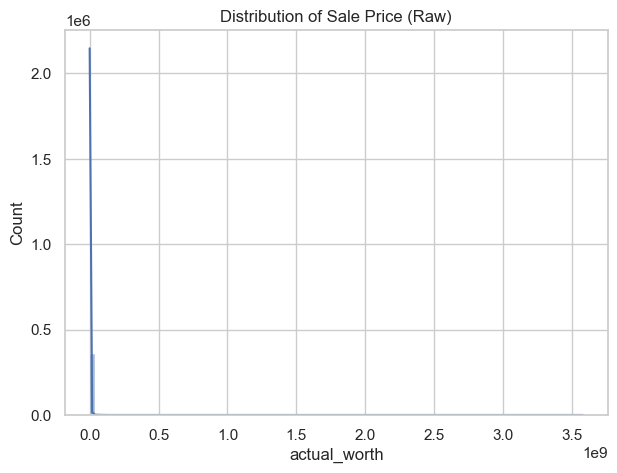

Raw price skewness: 105.26502745055744


In [5]:
plt.figure(figsize=(7,5))
sns.histplot(df["actual_worth"], bins=100, kde=True)
plt.title("Distribution of Sale Price (Raw)")
plt.xlabel("actual_worth")
plt.show()

print("Raw price skewness:", df["actual_worth"].skew())

## 6. Log Transformation of Target Variable

To reduce skewness and stabilize variance, a logarithmic transformation is applied to the target variable.

This improves linear model performance and makes residuals more homoscedastic.

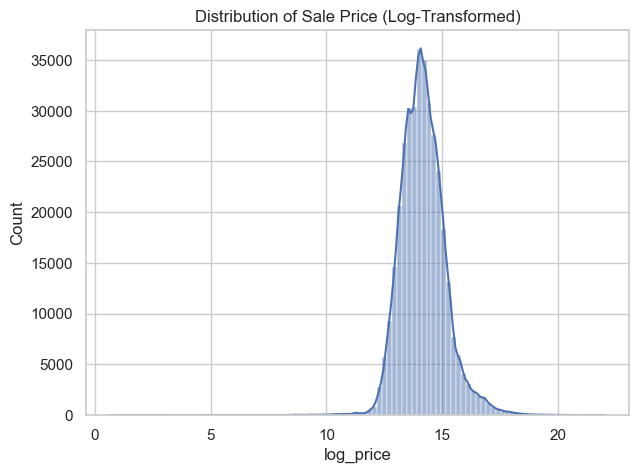

Log-transformed skewness: 0.4693076133956922


In [6]:
# Log-transform target
df["log_price"] = np.log1p(df["actual_worth"])

plt.figure(figsize=(7,5))
sns.histplot(df["log_price"], bins=100, kde=True)
plt.title("Distribution of Sale Price (Log-Transformed)")
plt.xlabel("log_price")
plt.show()

print("Log-transformed skewness:", df["log_price"].skew())

## 7. Feature Selection for Regression

Selected features include structural, temporal, and categorical location attributes.

Rows with missing `rooms_clean` are removed to ensure consistent numeric representation.

In [7]:
features = [
    "procedure_area",
    "rooms_clean",
    "has_parking",
    "property_type_en",
    "property_usage_en",
    "area_name_en",
    "reg_type_en",
    "year",
    "month"
]

df_model = df[features + ["log_price"]].copy()

print("Before dropna:", df_model.shape)
print("\nMissing values:\n", df_model.isnull().sum())

df_model = df_model.dropna()
print("\nAfter dropna:", df_model.shape)

Before dropna: (359066, 10)

Missing values:
 procedure_area           0
rooms_clean          75534
has_parking              0
property_type_en         0
property_usage_en        0
area_name_en             0
reg_type_en              0
year                     0
month                    0
log_price                0
dtype: int64

After dropna: (283532, 10)


## 8. Train/Test Split

Data is split into training (80%) and testing (20%) sets.

No stratification is used since the target variable is continuous.

In [8]:
X = df_model[features]
y = df_model["log_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (226825, 9)
Testing shape: (56707, 9)


## 9. Preprocessing Setup

Categorical features are one-hot encoded.
Numeric features are passed through.

Scaling will be applied only for Linear Regression.

In [9]:
categorical_features = [
    "property_type_en",
    "property_usage_en",
    "area_name_en",
    "reg_type_en"
]

numeric_features = [
    "procedure_area",
    "rooms_clean",
    "has_parking",
    "year",
    "month"
]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

## 10. Model 1: Linear Regression

In [10]:
lr_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("scale", StandardScaler(with_mean=False)),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

lr_pred = lr_pipeline.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results:")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2:", lr_r2)

Linear Regression Results:
MAE: 0.26955530540253547
RMSE: 0.3892265092851353
R2: 0.766279651451811


## 11. Model 2: Random Forest Regressor

In [11]:
rf_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results:")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

Random Forest Results:
MAE: 0.13923257931793517
RMSE: 0.2609468004582524
R2: 0.8949500971713333


## 12. Model Comparison Summary

In [12]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2": [lr_r2, rf_r2]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,0.269555,0.389227,0.76628
1,Random Forest,0.139233,0.260947,0.89495


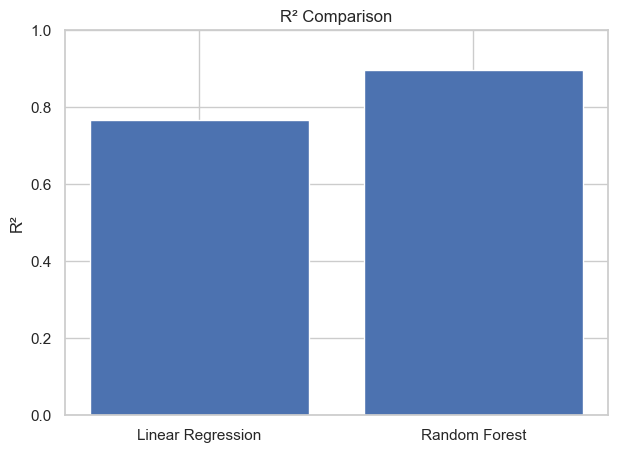

In [13]:
plt.figure(figsize=(7,5))
plt.bar(results["Model"], results["R2"])
plt.title("R² Comparison")
plt.ylabel("R²")
plt.ylim(0,1)
plt.show()

## 13. Cross-Validation (Model Stability)

5-fold cross-validation is used to evaluate model generalization stability.

In [16]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

lr_cv = cross_val_score(lr_pipeline, X, y, cv=cv, scoring="r2")
rf_cv = cross_val_score(rf_pipeline, X, y, cv=cv, scoring="r2")

print("Linear Regression CV R2: mean =", lr_cv.mean(), ", std =", lr_cv.std())
print("Random Forest CV R2: mean =", rf_cv.mean(), ", std =", rf_cv.std())

Linear Regression CV R2: mean = 0.7738870799958717 , std = 0.004085031557648668
Random Forest CV R2: mean = 0.9024184478961048 , std = 0.003856851992652792


## 14. Feature Importance Analysis

We extract:
- Impurity-based feature importance from Random Forest
- Absolute coefficient magnitude from Linear Regression

This helps identify the strongest drivers of pricing behavior.

In [17]:
# Extract feature names after preprocessing
ohe = rf_pipeline.named_steps["preprocess"].named_transformers_["cat"]
ohe_feature_names = ohe.get_feature_names_out(categorical_features)

all_feature_names = np.concatenate([ohe_feature_names, numeric_features])

rf_model = rf_pipeline.named_steps["model"]

rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=all_feature_names
).sort_values(ascending=False)

rf_importance.head(15)

procedure_area                                    0.607962
year                                              0.097968
area_name_en_Al Warsan First                      0.044606
area_name_en_Burj Khalifa                         0.026314
month                                             0.024012
reg_type_en_Existing Properties                   0.019487
area_name_en_Marsa Dubai                          0.016426
area_name_en_Business Bay                         0.015979
rooms_clean                                       0.012560
has_parking                                       0.009701
area_name_en_Palm Jumeirah                        0.009385
area_name_en_Al Barsha South Fourth               0.008696
reg_type_en_Off-Plan Properties                   0.008506
property_usage_en_Hospitality                     0.006387
area_name_en_Hadaeq Sheikh Mohammed Bin Rashid    0.005301
dtype: float64

In [18]:
# Extract linear model
lr_model = lr_pipeline.named_steps["model"]

# Coefficients correspond to same feature order
lr_coefficients = pd.Series(
    lr_model.coef_,
    index=all_feature_names
)

# Absolute importance
lr_importance = lr_coefficients.abs().sort_values(ascending=False)

lr_importance.head(15)

rooms_clean                            0.400707
year                                   0.179307
procedure_area                         0.163744
area_name_en_Burj Khalifa              0.144994
area_name_en_Al Warsan First           0.115323
area_name_en_Marsa Dubai               0.106414
area_name_en_Palm Jumeirah             0.105308
area_name_en_Al Barsha South Fourth    0.072740
area_name_en_Business Bay              0.070549
area_name_en_Wadi Al Safa 5            0.068591
area_name_en_Al Yelayiss 2             0.058466
reg_type_en_Off-Plan Properties        0.055443
reg_type_en_Existing Properties        0.055443
area_name_en_Al Wasl                   0.053951
area_name_en_Madinat Al Mataar         0.051400
dtype: float64

## 15. Interpretation of Pricing Drivers

Across both models, structural property attributes emerge as the strongest determinants of sale price.

Random Forest indicates that `procedure_area` is the dominant predictor, accounting for over 60% of total importance.

Linear Regression distributes weight across correlated structural variables such as `rooms_clean` and `procedure_area`, reflecting linear dependency among size-related features.

Temporal effects (`year`) and premium location indicators consistently contribute to predictive power.

These findings confirm that property size, transaction timing, and high-demand locations are primary drivers of pricing behavior in Dubai.

### Linear Regression: Predicted vs Actual (Log Scale)

This plot compares predicted and actual log-transformed sale prices.
Perfect predictions would lie on the diagonal line.

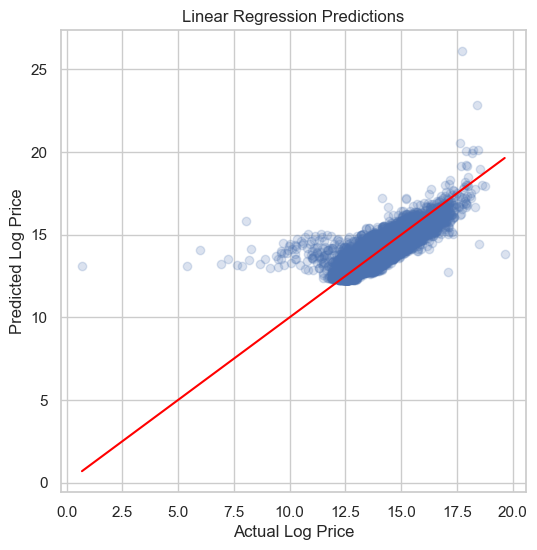

In [19]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, lr_pred, alpha=0.2)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.title("Linear Regression Predictions")
plt.show()

### Random Forest: Predicted vs Actual (Log Scale)

This plot shows the same comparison for the Random Forest model.

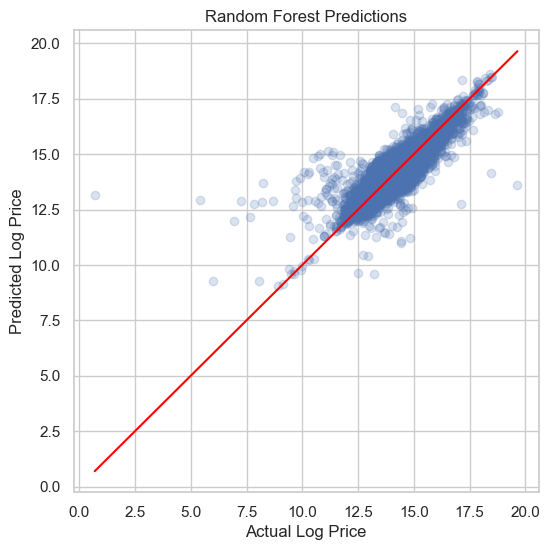

In [20]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_pred, alpha=0.2)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.title("Random Forest Predictions")
plt.show()